<a href="https://colab.research.google.com/github/jbarahonab-lang/SYS-2025-2/blob/main/SOLUCION_PARCIAL02_DICIEMBRE_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULACIONES PARA CADA UNO DE LOS LITERALES DEL PARCIAL 1 DEL 02 DE DICIEMBRE**

PRESENTADO POR: Julian Camilo Barahona Buitrago

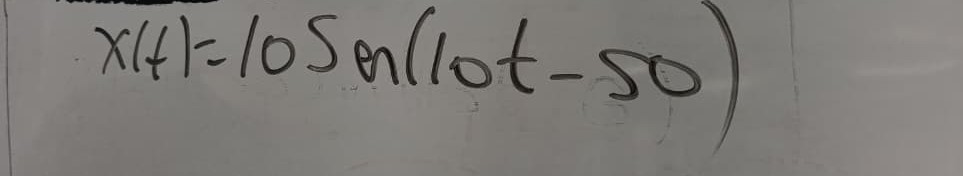

**1. Graficar 3 diferentes periodos de tiempo respetando el teorema de Nyquist:**

ANÁLISIS TEÓRICO DE LA SEÑAL
Señal: x(t) = 10·sin(10.0t + -50.0)
Frecuencia: f = 1.59154943 Hz
Período: T = 0.62831853 s

TEOREMA DE NYQUIST:
Frecuencia mínima de muestreo: f_Nyquist = 3.18309886 Hz
Período máximo permitido: T_s < 0.31415927 s
(equivalente a T_s < π/10 ≈ 0.31415927 s)
TRES CASOS DE MUESTREO
Caso  T_s (s)        f_s (Hz)       f_s/f_Nyq      Estado    
1     0.03141593     31.83098862    10.000         ✓ CUMPLE  
2     0.07853982     12.73239545    4.000          ✓ CUMPLE  
3     0.28274334     3.53677651     1.111          ✓ CUMPLE  


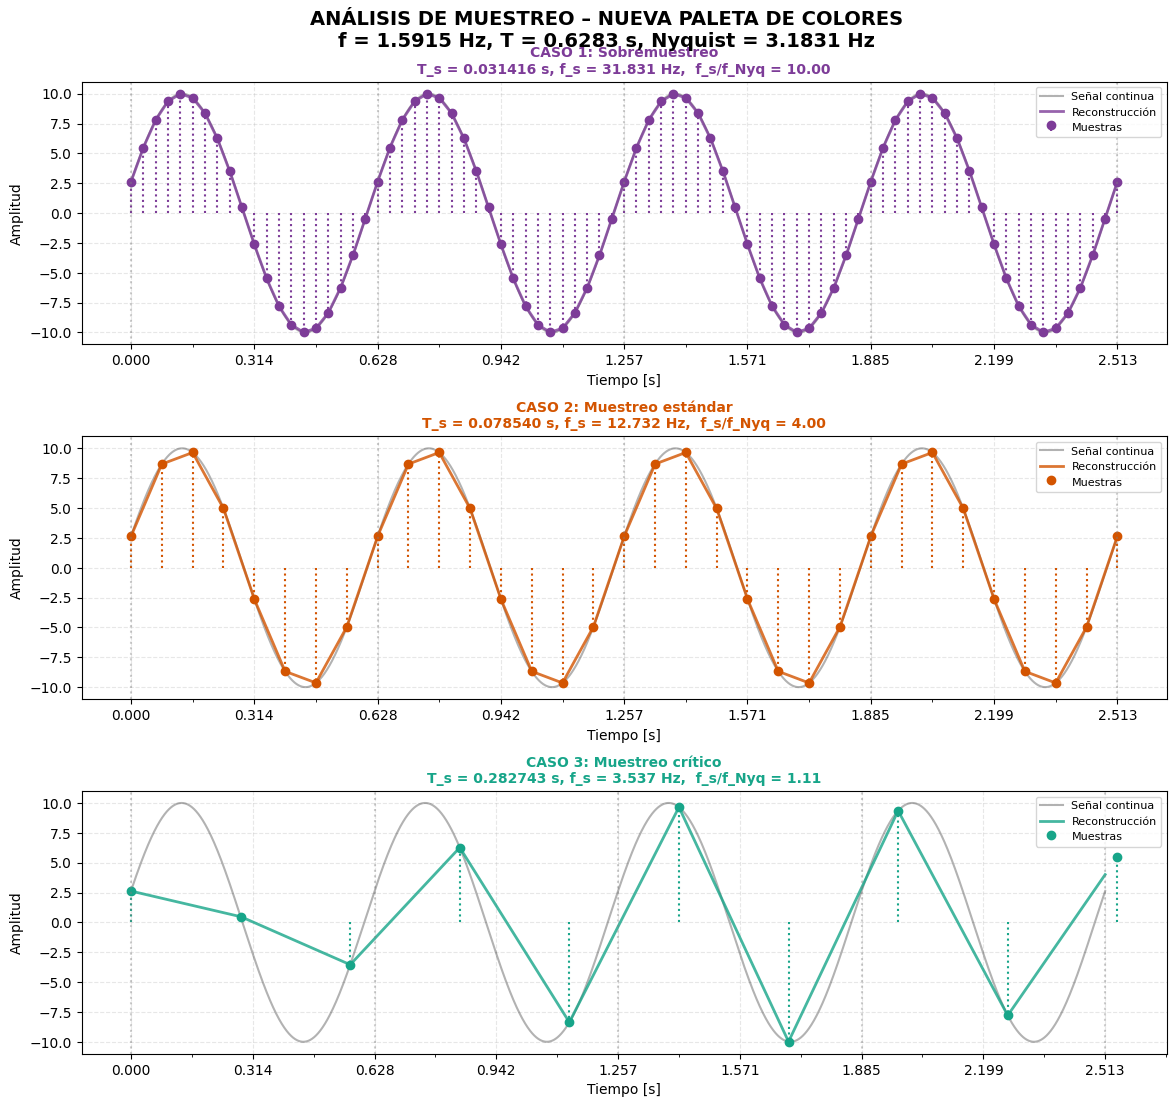

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# CONFIGURACIÓN GENERAL
np.set_printoptions(precision=8, suppress=True) #Define cuántos decimales se muestran al imprimir números en arreglos NumPy.

# Parámetros de la señal original
A = 10
omega = 10.0      # rad/s
phi = -50.0       # rad

# Cálculos exactos
f = omega / (2 * np.pi)
T_senal = 2 * np.pi / omega
f_nyquist = 2 * f
T_s_max = 1 / f_nyquist

print("ANÁLISIS TEÓRICO DE LA SEÑAL")
print(f"Señal: x(t) = {A}·sin({omega}t + {phi})")
print(f"Frecuencia: f = {f:.8f} Hz")
print(f"Período: T = {T_senal:.8f} s")

print("\nTEOREMA DE NYQUIST:")
print(f"Frecuencia mínima de muestreo: f_Nyquist = {f_nyquist:.8f} Hz")
print(f"Período máximo permitido: T_s < {T_s_max:.8f} s")
print(f"(equivalente a T_s < π/10 ≈ {np.pi/10:.8f} s)")

# COLORES PARA LAS GRÁFICAS
T_s_cases = {
    1: {"T_s": np.pi/100, "nombre": "Sobremuestreo",       "color": "#7D3C98"},  # Morado
    2: {"T_s": np.pi/40,  "nombre": "Muestreo estándar",   "color": "#D35400"},  # Naranja oscuro
    3: {"T_s": 0.9*np.pi/10, "nombre": "Muestreo crítico", "color": "#17A589"}   # Turquesa
}

print("TRES CASOS DE MUESTREO")
print(f"{'Caso':<6}{'T_s (s)':<15}{'f_s (Hz)':<15}{'f_s/f_Nyq':<15}{'Estado':<10}")

for i in T_s_cases:
    T_s = T_s_cases[i]["T_s"]
    f_s = 1 / T_s
    relacion = f_s / f_nyquist
    cumple = "✓ CUMPLE" if f_s > f_nyquist else "✗ NO"
    print(f"{i:<6}{T_s:<15.8f}{f_s:<15.8f}{relacion:<15.3f}{cumple:<10}")

# SEÑAL CONTINUA
num_periodos = 4
t_final = num_periodos * T_senal
t_continuo = np.linspace(0, t_final, 4000)
x_continuo = A * np.sin(omega * t_continuo + phi)

# FUNCIÓN DE LA GRÁFICA
def graficar_caso_muestreo(caso_num, ax):
    T_s = T_s_cases[caso_num]["T_s"]
    nombre = T_s_cases[caso_num]["nombre"]
    color = T_s_cases[caso_num]["color"]

    # Muestreo
    t_m = np.arange(0, t_final + T_s/2, T_s)
    x_m = A * np.sin(omega * t_m + phi)

    # Reconstrucción (interp. lineal para visualización)
    x_rec = np.interp(t_continuo, t_m, x_m)

    # Señal continua
    ax.plot(t_continuo, x_continuo, 'k-', alpha=0.3, linewidth=1.5, label="Señal continua")

    # Reconstrucción
    ax.plot(t_continuo, x_rec, color=color, linewidth=2, alpha=0.8, label="Reconstrucción")

    # Muestras
    markerline, stemlines, baseline = ax.stem(
    t_m, x_m,
    linefmt=':',   # Solo define el estilo de la línea (punteada)
    markerfmt='o', # Solo define el estilo del marcador (círculo)
    basefmt=" ",   # Sin línea base
    label="Muestras")

# Ajustar los colores de cada parte de la gráfica tipo "stem"
    plt.setp(stemlines, color=color)
    plt.setp(markerline, color=color, markerfacecolor=color)

    ax.set_title(
        f"CASO {caso_num}: {nombre}\n"
        f"T_s = {T_s:.6f} s, f_s = {1/T_s:.3f} Hz,  f_s/f_Nyq = {(1/T_s)/f_nyquist:.2f}",
        fontsize=10, fontweight="bold", color=color)

    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Amplitud")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=8)

    # Líneas verticales por período
    for n in range(num_periodos + 1):
        ax.axvline(n*T_senal, color="gray", linestyle=":", alpha=0.4)

    ax.xaxis.set_major_locator(MultipleLocator(T_senal/2))
    ax.xaxis.set_minor_locator(MultipleLocator(T_senal/4))

# FIGURA PRINCIPAL DE NYQUIST
fig = plt.figure(figsize=(14, 12))
gs = plt.GridSpec(3, 1, hspace=0.35, top=0.92)

for i in range(1, 4):
    ax = fig.add_subplot(gs[i-1])
    graficar_caso_muestreo(i, ax)

fig.suptitle(
    f"ANÁLISIS DE MUESTREO – NUEVA PALETA DE COLORES\n"
    f"f = {f:.4f} Hz, T = {T_senal:.4f} s, Nyquist = {f_nyquist:.4f} Hz",
    fontsize=14, fontweight="bold")

plt.show()

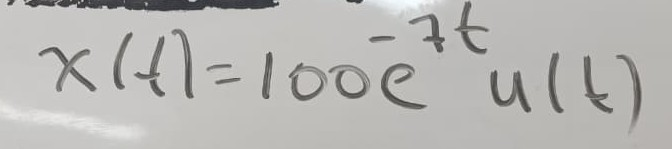

**2. ¿LA SEÑAL ANTERIOR CORRESPONDE A ENERGIA O POTENCIA?**

Energía aproximada = 724.34248
Energía teórica = 714.28571
Potencia media en [0, 2] = 362.17124
(A medida que T aumenta, la potencia media se acerca a 0)


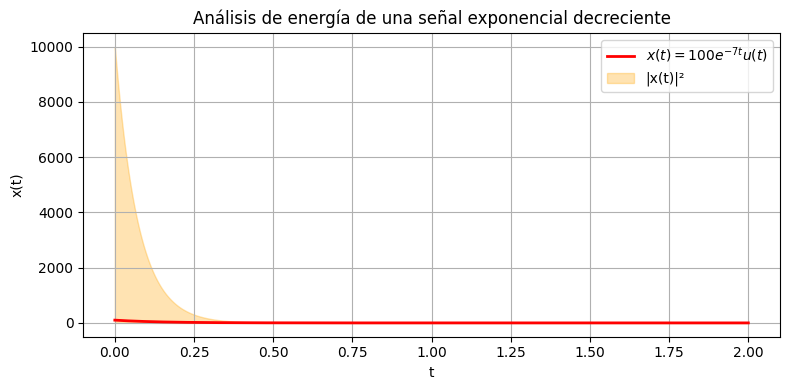

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# En este programa se analiza la señal x(t) = 100 e^{-7t} u(t).
# Es una exponencial que empieza en t=0 y cae rápidamente por el factor -7.

# Parámetros básicos
T = 2  # Tiempo máximo que vamos a observar (2 segundos)
t = np.linspace(0, T, 1000)  # Creo 1000 puntos entre 0 y T para buena resolución

# Definición de la señal
# Calculo la exponencial en cada punto de tiempo.
x = 100 * np.exp(-7 * t)

# Ahora se realiza el cálculo de la energía de la señal
# Como no podemos integrar hasta infinito, usamos una aproximación numérica.
dt = t[1] - t[0]  # Diferencia entre muestras, necesaria para aproximar la integral
energia = np.sum(x**2) * dt  # Suma de |x(t)|^2 multiplicada por dt (integral aproximada)

print(f'Energía aproximada = {energia:.5f}')

# Energía teórica de la señal (integral exacta de 0 a infinito)
# ∫₀∞ (100 e^{-7t})² dt = 10000 / 14
energia_teorica = 10000 / 14
print(f'Energía teórica = {energia_teorica:.5f}')

# Se verifica la Potencia media de la señal
# Como es una señal de energía finita, su potencia media tiende a 0 cuando T → ∞.
P_T = energia / T
print(f'Potencia media en [0, {T}] = {P_T:.5f}')
print('(A medida que T aumenta, la potencia media se acerca a 0)')

# Gráfica de la señal
plt.figure(figsize=(8, 4))

# Grafico la señal original
plt.plot(t, x, color='red', linewidth=2, label=r'$x(t) = 100 e^{-7t} u(t)$')

# Área sombreada de |x(t)|^2 (para visualizar de dónde sale la energía)
plt.fill_between(t, 0, x**2, color='orange', alpha=0.3, label='|x(t)|²')

# Detalles de la gráfica
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Análisis de energía de una señal exponencial decreciente')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

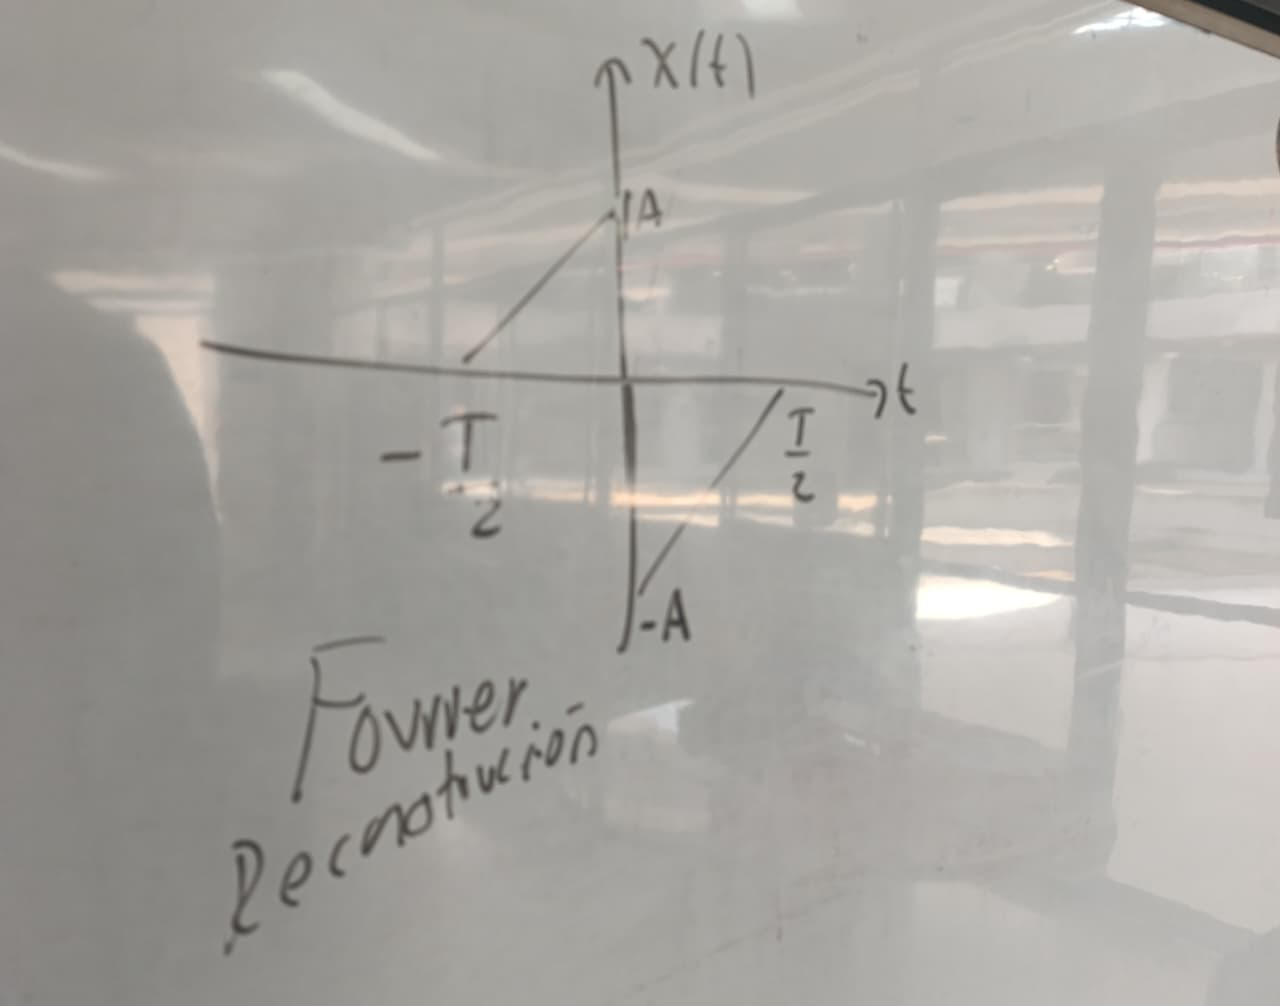**3. UTILIZAR SERIE DE FOURIER Y RECONSTRUCCION PARA LA ANTERIOR SEÑAL DADA**

/tmp/ipython-input-1380854478.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



             RESUMEN DE COEFICIENTES DE FOURIER             
n     bₙ              |bₙ|            Contribución        
------------------------------------------------------------
1     -2.546479       2.546479        127.3% del armónico fundamental
2     0.000000        0.000000        (armónico par nulo) 
3     -0.848826       0.848826        42.4% del armónico fundamental
4     0.000000        0.000000        (armónico par nulo) 
5     -0.509296       0.509296        25.5% del armónico fundamental
6     0.000000        0.000000        (armónico par nulo) 
7     -0.363783       0.363783        18.2% del armónico fundamental
8     0.000000        0.000000        (armónico par nulo) 
9     -0.282942       0.282942        14.1% del armónico fundamental
10    0.000000        0.000000        (armónico par nulo) 


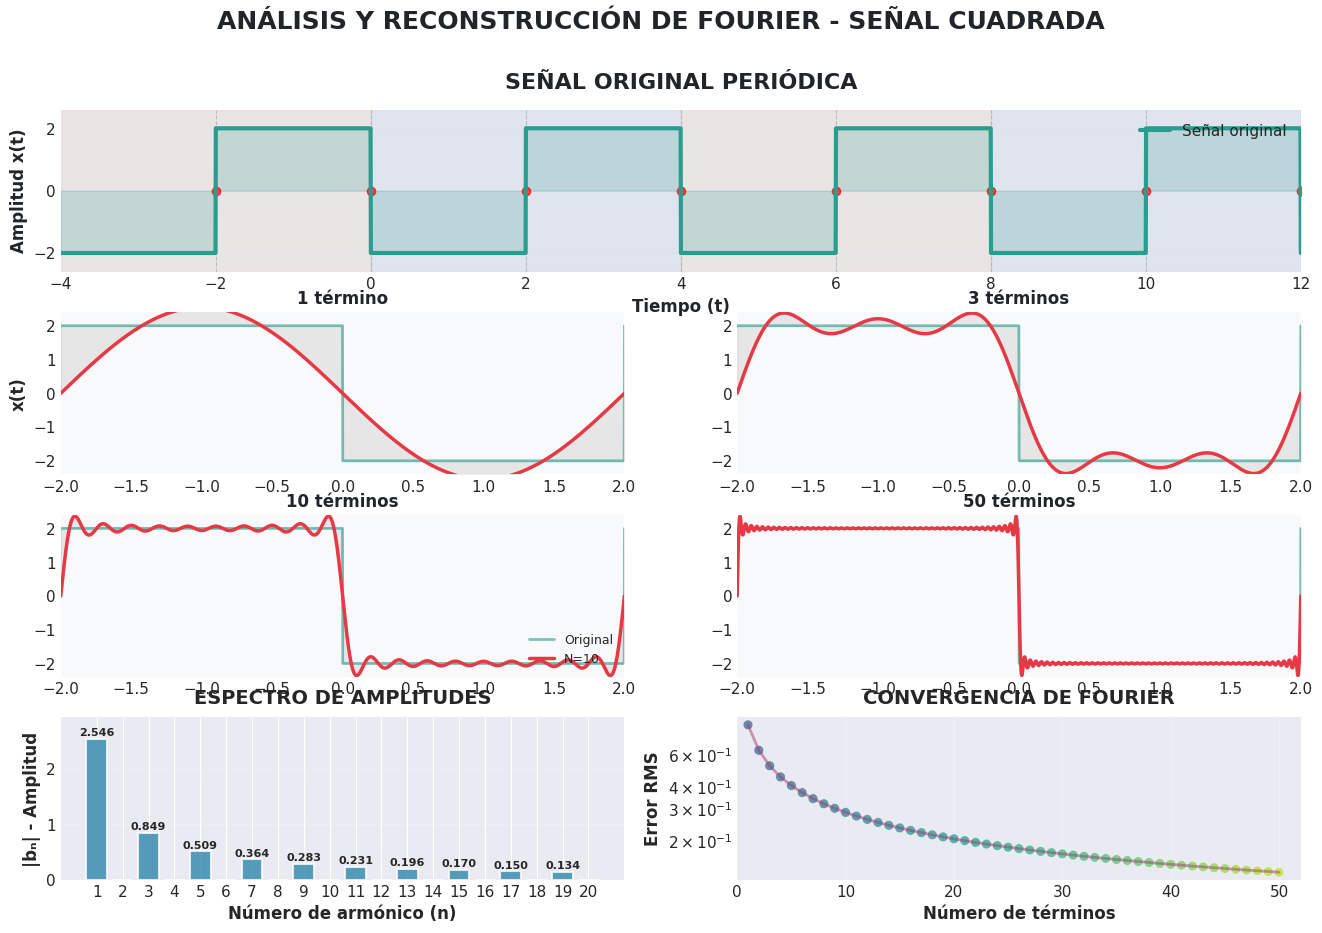

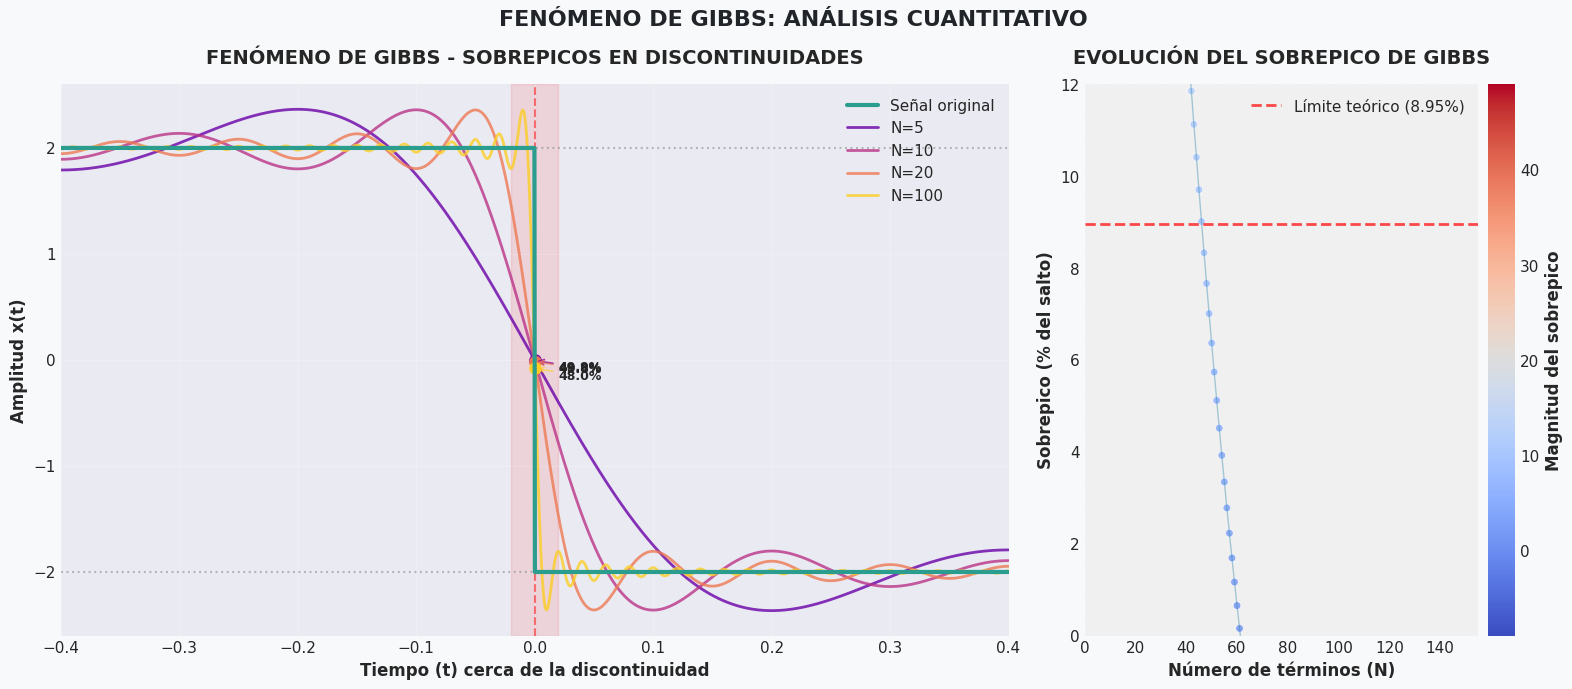

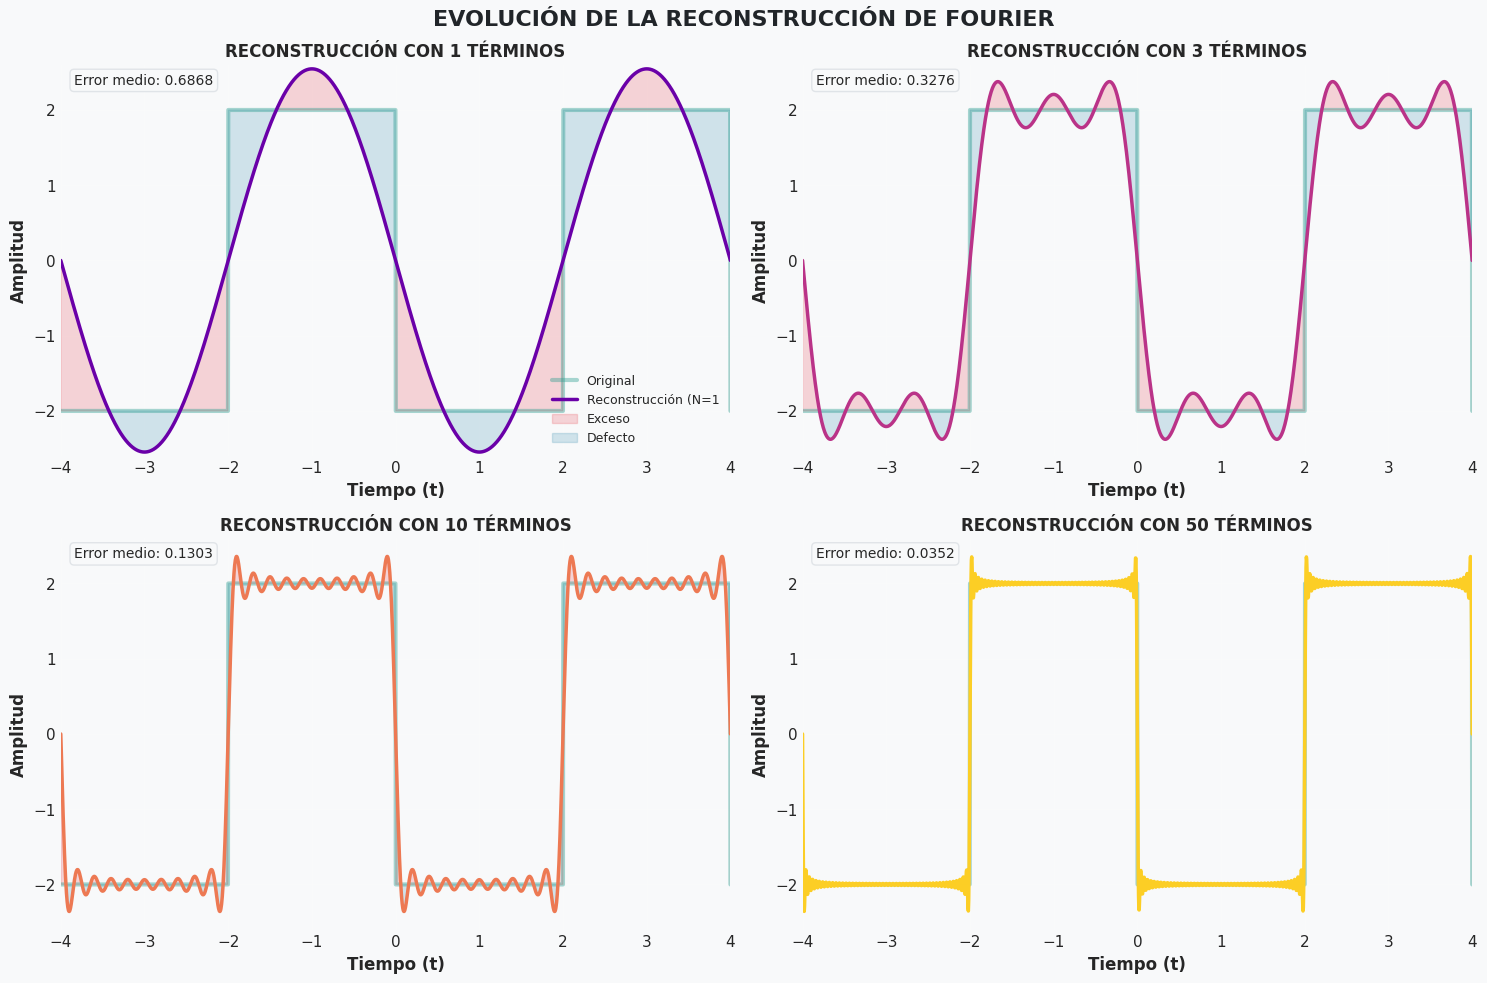


¡Visualizaciones completadas!
Señal analizada: Onda cuadrada con A=2.0, T=4.0
Se han generado 3 figuras con múltiples visualizaciones.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

#Colores para la estética
plt.style.use('seaborn-v0_8-darkgrid')
colors = {
    'primary': '#2E86AB',      # Azul principal
    'secondary': '#A23B72',    # Magenta
    'accent': '#F18F01',       # Naranja
    'signal': '#2A9D8F',       # Verde agua
    'fourier': '#E63946',      # Rojo vibrante
    'background': '#F8F9FA',   # Fondo claro
    'grid': '#DEE2E6',         # Gris claro
    'text': '#212529'          # Texto oscuro
}

# Configurar fuente
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'semibold'
})

# PARÁMETROS DE LA SEÑAL
A = 2.0        # Amplitud aumentada para mejor visualización
T = 4.0        # Período
omega0 = 2 * np.pi / T

# FUNCIONES
def señal_original(t):
    """Señal cuadrada periódica"""
    t_mod = ((t + T/2) % T) - T/2
    return np.where(t_mod < 0, A, -A)

def reconstrucción_fourier(t, N_terms):
    """Reconstrucción con N términos"""
    resultado = np.zeros_like(t)
    for k in range(1, N_terms + 1):
        n = 2*k - 1  # Solo impares
        bn = -4*A/(np.pi * n)
        resultado += bn * np.sin(n * omega0 * t)
    return resultado

# GRÁFICO 1: VISUALIZACIÓN COMPLETA DE LA FUNCIÓN

fig1 = plt.figure(figsize=(16, 10))
# Changed GridSpec to 4 rows to accommodate all plots
gs = gridspec.GridSpec(4, 2, figure=fig1, hspace=0.25, wspace=0.2)

# 1A: Señal Original (grande)
ax1 = fig1.add_subplot(gs[0, :])
t_full = np.linspace(-T, 3*T, 4000)
señal_full = señal_original(t_full)

# Crear fondo para diferenciar períodos
for i in range(-1, 4):
    if i % 2 == 0:
        ax1.axvspan(i*T, (i+1)*T, alpha=0.05, color=colors['primary'], zorder=0)
    else:
        ax1.axvspan(i*T, (i+1)*T, alpha=0.05, color=colors['accent'], zorder=0)

ax1.plot(t_full, señal_full, color=colors['signal'], linewidth=3,
         label='Señal original', zorder=5)
ax1.fill_between(t_full, señal_full, alpha=0.2, color=colors['signal'])

# Marcar discontinuidades
discontinuidades = np.arange(-T/2, 3*T + T/2, T/2)
for d in discontinuidades:
    ax1.axvline(d, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
    ax1.plot(d, 0, 'o', color='red', markersize=6, alpha=0.7)

ax1.set_xlabel('Tiempo (t)', fontweight='bold', color=colors['text'])
ax1.set_ylabel('Amplitud x(t)', fontweight='bold', color=colors['text'])
ax1.set_title('SEÑAL ORIGINAL PERIÓDICA',
              fontsize=16, fontweight='bold', color=colors['text'], pad=15)
ax1.grid(True, alpha=0.3, linestyle='-', color=colors['grid'])
ax1.set_xlim(-T, 3*T)
ax1.set_ylim(-A*1.3, A*1.3)
ax1.legend(loc='upper right', framealpha=0.9, shadow=True)

# 1B: Reconstrucciones progresivas
N_progresivos = [1, 3, 10, 50]
t_detail = np.linspace(-T/2, T/2, 2000)
axes_prog = []

for idx, N in enumerate(N_progresivos):
    # Adjusted subplot placement to use gs[1,:] and gs[2,:] for 2x2 grid
    if idx < 2:
        ax = fig1.add_subplot(gs[1, idx])
    else:
        ax = fig1.add_subplot(gs[2, idx-2])
    axes_prog.append(ax)

    # Fondo degradado
    ax.set_facecolor(colors['background'])

    # Señal original en el período
    señal_periodo = señal_original(t_detail)
    ax.plot(t_detail, señal_periodo, color=colors['signal'],
            linewidth=2, alpha=0.6, label='Original')

    # Reconstrucción
    fourier_rec = reconstrucción_fourier(t_detail, N)
    ax.plot(t_detail, fourier_rec, color=colors['fourier'],
            linewidth=2.5, label=f'N={N}')

    # Rellenar diferencia
    ax.fill_between(t_detail, señal_periodo, fourier_rec,
                    alpha=0.15, color='gray')

    ax.set_title(f'{N} término{"s" if N>1 else ""}',
                 fontsize=12, fontweight='bold', color=colors['text'])
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.set_xlim(-T/2, T/2)
    ax.set_ylim(-A*1.2, A*1.2)

    if idx == 0:
        ax.set_ylabel('x(t)', fontweight='bold')
    if idx == 2:
        ax.legend(loc='lower right', fontsize=9)

# 1C: Espectro de amplitudes
# Adjusted subplot placement to the new 4th row
ax3 = fig1.add_subplot(gs[3, 0])
n_values = np.arange(1, 21)
bn_values = np.where(n_values % 2 == 1, -4*A/(np.pi * n_values), 0)

# Gráfico de barras con colores alternados
bars = ax3.bar(n_values, np.abs(bn_values),
               color=[colors['primary'] if n%2==1 else colors['secondary'] for n in n_values],
               edgecolor='white', linewidth=1.5, alpha=0.8)

# Etiquetas
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    if height > 0:
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax3.set_xlabel('Número de armónico (n)', fontweight='bold')
ax3.set_ylabel('|bₙ| - Amplitud', fontweight='bold')
ax3.set_title('ESPECTRO DE AMPLITUDES', fontsize=14, fontweight='bold', pad=10)
ax3.set_xticks(n_values)
ax3.set_ylim(0, max(np.abs(bn_values))*1.15)
ax3.grid(True, alpha=0.2, axis='y')

# 1D: Error de reconstrucción
# Adjusted subplot placement to the new 4th row
ax4 = fig1.add_subplot(gs[3, 1])
N_range = np.arange(1, 51)
error_rms = []

for N in N_range:
    rec = reconstrucción_fourier(t_detail, N)
    orig = señal_original(t_detail)
    error = np.sqrt(np.mean((rec - orig)**2))
    error_rms.append(error)

# Gráfico de error con degradado de color
colors_error = plt.cm.viridis(np.linspace(0.3, 0.9, len(N_range)))
scatter = ax4.scatter(N_range, error_rms, c=colors_error, s=50, alpha=0.7, edgecolors='white', linewidth=0.5)

# Línea de tendencia
ax4.plot(N_range, error_rms, color=colors['secondary'], linewidth=2, alpha=0.5)

ax4.set_xlabel('Número de términos', fontweight='bold')
ax4.set_ylabel('Error RMS', fontweight='bold')
ax4.set_title('CONVERGENCIA DE FOURIER', fontsize=14, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')
ax4.set_xlim(0, 52)

# Añadir anotación
ax4.annotate('Error decrece con más términos', xy=(30, 0.1),
             xytext=(10, 0.5), fontsize=10,
             arrowprops=dict(arrowstyle='->', color=colors['accent'], lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", facecolor=colors['background'], alpha=0.9))

plt.suptitle('ANÁLISIS Y RECONSTRUCCIÓN DE FOURIER - SEÑAL CUADRADA',
             fontsize=18, fontweight='bold', color=colors['text'], y=0.98)
plt.tight_layout()

# GRÁFICO 2: FENÓMENO DE GIBBS AL DETALLE
fig2, (ax_gibbs1, ax_gibbs2) = plt.subplots(1, 2, figsize=(16, 7),
                                             gridspec_kw={'width_ratios': [2, 1]})
fig2.patch.set_facecolor(colors['background'])

# Detalle del fenómeno de Gibbs
t_gibbs = np.linspace(-0.4, 0.4, 2000)
señal_gibbs = señal_original(t_gibbs)

# Paleta de colores para diferentes N
N_gibbs = [5, 10, 20, 100]
cmap_gibbs = plt.cm.plasma(np.linspace(0.2, 0.9, len(N_gibbs)))

# Gráfico principal de Gibbs
ax_gibbs1.plot(t_gibbs, señal_gibbs, color=colors['signal'],
               linewidth=3, label='Señal original', zorder=10)

for i, N in enumerate(N_gibbs):
    rec_gibbs = reconstrucción_fourier(t_gibbs, N)
    ax_gibbs1.plot(t_gibbs, rec_gibbs, color=cmap_gibbs[i],
                   linewidth=2, alpha=0.8, label=f'N={N}')

    # Encontrar sobrepico máximo
    idx_pos = np.where(t_gibbs > 0)[0][:len(t_gibbs)//4]
    overshoot = np.max(rec_gibbs[idx_pos]) - (-A)
    overshoot_percent = (overshoot / (2*A)) * 100

    # Marcar sobrepico
    max_idx = np.argmax(rec_gibbs[idx_pos])
    max_t = t_gibbs[idx_pos[max_idx]]
    max_val = rec_gibbs[idx_pos[max_idx]]

    ax_gibbs1.plot(max_t, max_val, 'o', color=cmap_gibbs[i], markersize=8)
    ax_gibbs1.annotate(f'{overshoot_percent:.1f}%',
                      xy=(max_t, max_val),
                      xytext=(max_t+0.02, max_val-0.1),
                      fontsize=9, fontweight='bold',
                      arrowprops=dict(arrowstyle='->', color=cmap_gibbs[i], alpha=0.7))

# Zona de discontinuidad
ax_gibbs1.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax_gibbs1.axhline(-A, color='gray', linestyle=':', alpha=0.5)
ax_gibbs1.axhline(A, color='gray', linestyle=':', alpha=0.5)

ax_gibbs1.set_xlabel('Tiempo (t) cerca de la discontinuidad', fontweight='bold')
ax_gibbs1.set_ylabel('Amplitud x(t)', fontweight='bold')
ax_gibbs1.set_title('FENÓMENO DE GIBBS - SOBREPICOS EN DISCONTINUIDADES',
                    fontsize=14, fontweight='bold', pad=15)
ax_gibbs1.grid(True, alpha=0.2)
ax_gibbs1.legend(loc='upper right', framealpha=0.9)
ax_gibbs1.set_xlim(-0.4, 0.4)
ax_gibbs1.set_ylim(-A*1.3, A*1.3)

# Fondo para resaltar
ax_gibbs1.axvspan(-0.02, 0.02, alpha=0.1, color='red', zorder=0)

# Segundo gráfico: Evolución del sobrepico
ax_gibbs2.set_facecolor('#F0F0F0')
N_evolution = np.arange(1, 151)
overshoots = []

for N in N_evolution:
    rec = reconstrucción_fourier(np.array([0.01]), N)  # Punto cerca de la discontinuidad
    overshoot = (rec[0] - (-A)) / (2*A) * 100  # Porcentaje del salto
    overshoots.append(overshoot)

# Gráfico con colormap
norm = plt.Normalize(min(overshoots), max(overshoots))
colors_evo = plt.cm.coolwarm(norm(overshoots))

sc = ax_gibbs2.scatter(N_evolution, overshoots, c=colors_evo,
                       s=30, alpha=0.8, edgecolors='white', linewidth=0.5)

# Línea de tendencia
ax_gibbs2.plot(N_evolution, overshoots, color=colors['primary'],
               linewidth=1, alpha=0.4)

# Línea del límite teórico (8.95%)
ax_gibbs2.axhline(y=8.95, color='red', linestyle='--', linewidth=2,
                  alpha=0.7, label='Límite teórico (8.95%)')

ax_gibbs2.set_xlabel('Número de términos (N)', fontweight='bold')
ax_gibbs2.set_ylabel('Sobrepico (% del salto)', fontweight='bold')
ax_gibbs2.set_title('EVOLUCIÓN DEL SOBREPICO DE GIBBS',
                    fontsize=14, fontweight='bold', pad=15)
ax_gibbs2.grid(True, alpha=0.3, linestyle=':')
ax_gibbs2.legend(loc='upper right')
ax_gibbs2.set_xlim(0, 155)
ax_gibbs2.set_ylim(0, 12)

# Barra de color
cbar = fig2.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm),
                     ax=ax_gibbs2, orientation='vertical', pad=0.02)
cbar.set_label('Magnitud del sobrepico', fontweight='bold')

plt.suptitle('FENÓMENO DE GIBBS: ANÁLISIS CUANTITATIVO',
             fontsize=16, fontweight='bold', color=colors['text'], y=0.98)
plt.tight_layout()

# GRÁFICO 3: ANIMACIÓN ESTÁTICA
fig3 = plt.figure(figsize=(15, 10))
fig3.patch.set_facecolor(colors['background'])

# 4 cuadros clave de la reconstrucción
N_keyframes = [1, 3, 10, 50]
t_anim = np.linspace(-T, T, 2000)

for idx, N in enumerate(N_keyframes):
    ax = fig3.add_subplot(2, 2, idx+1)

    # Fondo con gradiente sutil
    ax.set_facecolor(colors['background'])

    # Señal original
    señal_anim = señal_original(t_anim)
    ax.plot(t_anim, señal_anim, color=colors['signal'],
            linewidth=3, alpha=0.4, label='Original')

    # Reconstrucción
    rec_anim = reconstrucción_fourier(t_anim, N)
    ax.plot(t_anim, rec_anim, color=cmap_gibbs[idx],
            linewidth=2.5, label=f'Reconstrucción (N={N}')

    # Rellenar área
    ax.fill_between(t_anim, señal_anim, rec_anim,
                    where=(rec_anim > señal_anim),
                    color=colors['fourier'], alpha=0.2, label='Exceso')
    ax.fill_between(t_anim, señal_anim, rec_anim,
                    where=(rec_anim < señal_anim),
                    color=colors['primary'], alpha=0.2, label='Defecto')

    # Información estadística
    error = np.mean(np.abs(rec_anim - señal_anim))
    ax.text(0.02, 0.95, f'Error medio: {error:.4f}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3",
                     facecolor=colors['background'],
                     edgecolor=colors['grid'], alpha=0.9))

    ax.set_title(f'RECONSTRUCCIÓN CON {N} TÉRMINOS',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Tiempo (t)')
    ax.set_ylabel('Amplitud')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-T, T)
    ax.set_ylim(-A*1.3, A*1.3)

    if idx == 0:
        ax.legend(loc='lower right', fontsize=9)

plt.suptitle('EVOLUCIÓN DE LA RECONSTRUCCIÓN DE FOURIER',
             fontsize=16, fontweight='bold', color=colors['text'], y=0.98)
plt.tight_layout()

# TABLA RESUMEN DE COEFICIENTES
print("\n" + "="*60)
print("RESUMEN DE COEFICIENTES DE FOURIER".center(60))
print("="*60)
print(f"{'n':<5} {'bₙ':<15} {'|bₙ|':<15} {'Contribución':<20}")
print("-"*60)

for n in range(1, 11):
    if n % 2 == 1:
        bn = -4*A/(np.pi * n)
        contrib = f"{abs(bn)/A*100:.1f}% del armónico fundamental"
        print(f"{n:<5} {bn:<15.6f} {abs(bn):<15.6f} {contrib:<20}")
    else:
        print(f"{n:<5} {'0.000000':<15} {'0.000000':<15} {'(armónico par nulo)':<20}")

print("="*60)

# MOSTRAR TODOS LOS GRÁFICOS DE LOS RESULTADOS FINALES
plt.show()

print("\n¡Visualizaciones completadas!")
print(f"Señal analizada: Onda cuadrada con A={A}, T={T}")
print("Se han generado 3 figuras con múltiples visualizaciones.")

**4. USAR ELSE IF (ELIF) Y ELSE EN PHYTHON**

**1 EJEMPLO BÁSICO:** Número Positivo, Negativo o Cero

In [24]:
numero = float(input("Ingresa un número: "))

if numero > 0:
    print("El número es POSITIVO")
elif numero < 0:
    print("El número es NEGATIVO")
else:
    print("El número es CERO")

Ingresa un número: 1
El número es POSITIVO


**2 EJEMPLO BÁSICO:** Par o Impar

In [25]:
numero = int(input("Ingresa un número entero: "))

if numero % 2 == 0:
    print(f"{numero} es PAR")
else:
    print(f"{numero} es IMPAR")

Ingresa un número entero: 2
2 es PAR


**3 EJEMPLO DIAS DE LA SEMANA**

In [26]:
numero_dia = int(input("Ingresa un número del 1 al 7: "))

if numero_dia == 1:
    print("Lunes")
elif numero_dia == 2:
    print("Martes")
elif numero_dia == 3:
    print("Miércoles")
elif numero_dia == 4:
    print("Jueves")
elif numero_dia == 5:
    print("Viernes")
elif numero_dia == 6:
    print("Sábado")
elif numero_dia == 7:
    print("Domingo")
else:
    print("Número inválido. Debe ser entre 1 y 7")

Ingresa un número del 1 al 7: 3
Miércoles


**1 EJEMPLO INTERMEDIO:** Calculadora Simple

In [28]:
print("CALCULADORA SIMPLE")
print("Operaciones disponibles:")
print("+ : Suma")
print("- : Resta")
print("* : Multiplicación")
print("/ : División")

num1 = float(input("Primer número: "))
operador = input("Operador (+, -, *, /): ")
num2 = float(input("Segundo número: "))

if operador == "+":
    resultado = num1 + num2
    print(f"{num1} + {num2} = {resultado}")
elif operador == "-":
    resultado = num1 - num2
    print(f"{num1} - {num2} = {resultado}")
elif operador == "*":
    resultado = num1 * num2
    print(f"{num1} * {num2} = {resultado}")
elif operador == "/":
    if num2 != 0:
        resultado = num1 / num2
        print(f"{num1} / {num2} = {resultado}")
    else:
        print("ERROR: No se puede dividir por cero")
else:
    print("Operador no válido. Usa +, -, * o /")

CALCULADORA SIMPLE
Operaciones disponibles:
+ : Suma
- : Resta
* : Multiplicación
/ : División
Primer número: 12
Operador (+, -, *, /): +
Segundo número: 2
12.0 + 2.0 = 14.0


**2 EJEMPLO INTERMEDIO:** Sistema de Descuentos

In [32]:
print("SISTEMA DE DESCUENTOS")

total_compra = float(input("Total de la compra: $"))
es_miembro = input("¿Es miembro? (sí/no): ").lower()

if es_miembro == "sí" or es_miembro == "si":
    if total_compra > 1000:
        descuento = 20
    elif total_compra > 500:
        descuento = 15
    elif total_compra > 100:
        descuento = 10
    else:
        descuento = 5
else:
    if total_compra > 1000:
        descuento = 10
    elif total_compra > 500:
        descuento = 5
    else:
        descuento = 0

monto_descuento = total_compra * (descuento / 100)
total_a_pagar = total_compra - monto_descuento

print(f"\nFACTURA")
print(f"Total compra: ${total_compra:.2f}")
print(f"Descuento aplicado: {descuento}%")
print(f"Monto descuento: ${monto_descuento:.2f}")
print(f"Total a pagar: ${total_a_pagar:.2f}")

SISTEMA DE DESCUENTOS
Total de la compra: $1100
¿Es miembro? (sí/no): si

FACTURA
Total compra: $1100.00
Descuento aplicado: 20%
Monto descuento: $220.00
Total a pagar: $880.00


**1 EJEMPLO COMPLETO:** Sistema Bancario Simple

In [43]:
class CuentaBancaria:
    def __init__(self, titular, saldo_inicial=0):
        self.titular = titular
        self.saldo = saldo_inicial
        self.intentos_fallidos = 0
        self.bloqueada = False

    def verificar_estado_cuenta(self):
        """Verifica el estado de la cuenta usando if-elif-else"""
        print(f"\nESTADO DE CUENTA: {self.titular}")

        if self.bloqueada:
            print("❌ CUENTA BLOQUEADA")
            print("Motivo: Demasiados intentos fallidos")
            print("Acción: Contactar al banco para desbloquear")

        elif self.saldo < 0:
            print("CUENTA EN NÚMEROS ROJOS")
            print(f"Saldo actual: ${self.saldo:.2f}")
            print("Acción: Depositar fondos urgentemente")

        elif self.saldo < 100:
            print("CUENTA CON SALDO BAJO")
            print(f"Saldo actual: ${self.saldo:.2f}")
            print("Recomendación: Mantener más de $100")

        elif self.saldo < 1000:
            print("CUENTA ACTIVA")
            print(f"Saldo actual: ${self.saldo:.2f}")
            print("Estado: Normal")

        elif self.saldo < 10000:
            print("CUENTA CON BUEN SALDO")
            print(f"Saldo actual: ${self.saldo:.2f}")
            print("Ventajas: Acceso a beneficios especiales")

        else:
            print("CUENTA PREMIUM")
            print(f"Saldo actual: ${self.saldo:.2f}")
            print("Beneficios: Asesor personal, tasas preferenciales")

        print("=" * 40)

    def intentar_acceso(self, pin_correcto=1234):
        """Simula intento de acceso al cajero"""
        print(f"\nIntento de acceso para: {self.titular}")

        if self.bloqueada:
            print("Acceso denegado: Cuenta bloqueada")
            return False

        # Simulamos 3 intentos de PIN
        for intento in range(1, 4):
            pin_ingresado = int(input(f"Intento {intento}/3 - Ingrese PIN: "))

            if pin_ingresado == pin_correcto:
                print("✅ Acceso concedido")
                self.intentos_fallidos = 0
                return True
            else:
                print("❌ PIN incorrecto")
                self.intentos_fallidos += 1

        # Si llegamos aquí, 3 intentos fallidos
        print("Demasiados intentos fallidos")
        self.bloqueada = True
        return False

# Crear y probar cuentas
print("SISTEMA BANCARIO\n")

# Crear cuentas con diferentes saldos
cuenta1 = CuentaBancaria("", )
cuenta2 = CuentaBancaria("María García", 10000)
cuenta3 = CuentaBancaria("Carlos López", -50)

# Verificar estado de cada cuenta
cuenta1.verificar_estado_cuenta()
cuenta2.verificar_estado_cuenta()
cuenta3.verificar_estado_cuenta()

# Simular intento de acceso (puedes probar con PIN incorrecto varias veces)
# cuenta1.intentar_acceso()

SISTEMA BANCARIO


ESTADO DE CUENTA: 
CUENTA CON SALDO BAJO
Saldo actual: $0.00
Recomendación: Mantener más de $100

ESTADO DE CUENTA: María García
CUENTA PREMIUM
Saldo actual: $10000.00
Beneficios: Asesor personal, tasas preferenciales

ESTADO DE CUENTA: Carlos López
CUENTA EN NÚMEROS ROJOS
Saldo actual: $-50.00
Acción: Depositar fondos urgentemente


**2. EJEMPLO COMPLETO:** Sistema de Gestión de Biblioteca

In [ ]:
class Libro:
    def __init__(self, titulo, autor, paginas):
        self.titulo = titulo
        self.autor = autor
        self.paginas = paginas
        self.disponible = True
        self.quien_tiene = None

class Biblioteca:
    def __init__(self):
        self.libros = []
        self.usuarios = {}

    def agregar_libro(self):
        print("\n📚 AGREGAR NUEVO LIBRO")
        titulo = input("Título: ")
        autor = input("Autor: ")
        paginas = int(input("Número de páginas: "))

        libro = Libro(titulo, autor, paginas)
        self.libros.append(libro)
        print(f"✅ Libro '{titulo}' agregado correctamente")

    def clasificar_libro(self, libro):
        """Clasifica un libro por su extensión"""
        if libro.paginas < 100:
            return "Corto"
        elif libro.paginas < 300:
            return "Mediano"
        elif libro.paginas < 500:
            return "Largo"
        else:
            return "Muy Largo"

    def determinar_categoria(self, titulo):
        """Determina categoría basada en palabras clave"""
        titulo_lower = titulo.lower()

        if any(palabra in titulo_lower for palabra in ["programación", "python", "java", "código"]):
            return "Tecnología"
        elif any(palabra in titulo_lower for palabra in ["amor", "romance", "corazón"]):
            return "Romance"
        elif any(palabra in titulo_lower for palabra in ["misterio", "crimen", "detective"]):
            return "Misterio"
        elif any(palabra in titulo_lower for palabra in ["ciencia", "universo", "planeta"]):
            return "Ciencia"
        elif any(palabra in titulo_lower for palabra in ["historia", "guerra", "antiguo"]):
            return "Historia"
        else:
            return "General"

    def prestar_libro(self):
        if not self.libros:
            print("❌ No hay libros en la biblioteca")
            return

        print("\n📖 PRESTAR LIBRO")

        # Mostrar libros disponibles
        disponibles = [libro for libro in self.libros if libro.disponible]

        if not disponibles:
            print("❌ No hay libros disponibles para préstamo")
            return

        print("Libros disponibles:")
        for i, libro in enumerate(disponibles, 1):
            print(f"{i}. '{libro.titulo}' por {libro.autor}")

        try:
            seleccion = int(input("\nSelecciona el número del libro: ")) - 1

            if 0 <= seleccion < len(disponibles):
                libro = disponibles[seleccion]
                usuario = input("Nombre del usuario: ")

                libro.disponible = False
                libro.quien_tiene = usuario

                # Registrar usuario si no existe
                if usuario not in self.usuarios:
                    self.usuarios[usuario] = []

                self.usuarios[usuario].append(libro.titulo)

                print(f"✅ Libro '{libro.titulo}' prestado a {usuario}")
            else:
                print("❌ Selección no válida")
        except ValueError:
            print("❌ Ingresa un número válido")

    def devolver_libro(self):
        print("\n↩️ DEVOLVER LIBRO")
        usuario = input("Nombre del usuario: ")

        if usuario not in self.usuarios or not self.usuarios[usuario]:
            print("❌ Este usuario no tiene libros prestados")
            return

        print(f"Libros prestados a {usuario}:")
        for i, titulo in enumerate(self.usuarios[usuario], 1):
            print(f"{i}. {titulo}")

        try:
            seleccion = int(input("\nSelecciona el número del libro a devolver: ")) - 1

            if 0 <= seleccion < len(self.usuarios[usuario]):
                titulo_devolver = self.usuarios[usuario][seleccion]

                # Buscar el libro en la biblioteca
                for libro in self.libros:
                    if libro.titulo == titulo_devolver:
                        libro.disponible = True
                        libro.quien_tiene = None
                        break

                # Remover de la lista del usuario
                self.usuarios[usuario].pop(seleccion)

                # Si el usuario no tiene más libros, removerlo
                if not self.usuarios[usuario]:
                    del self.usuarios[usuario]

                print(f"✅ Libro '{titulo_devolver}' devuelto correctamente")
            else:
                print("❌ Selección no válida")
        except ValueError:
            print("❌ Ingresa un número válido")

    def mostrar_estadisticas(self):
        print("\n📊 ESTADÍSTICAS DE LA BIBLIOTECA")
        print("="*40)

        total_libros = len(self.libros)
        libros_disponibles = sum(1 for libro in self.libros if libro.disponible)
        libros_prestados = total_libros - libros_disponibles

        print(f"Total de libros: {total_libros}")
        print(f"Libros disponibles: {libros_disponibles}")
        print(f"Libros prestados: {libros_prestados}")
        print(f"Usuarios registrados: {len(self.usuarios)}")

        if total_libros > 0:
            # Clasificación por extensión
            cortos = sum(1 for libro in self.libros if libro.paginas < 100)
            medianos = sum(1 for libro in self.libros if 100 <= libro.paginas < 300)
            largos = sum(1 for libro in self.libros if 300 <= libro.paginas < 500)
            muy_largos = sum(1 for libro in self.libros if libro.paginas >= 500)

            print("\n📏 CLASIFICACIÓN POR EXTENSIÓN:")
            print(f"  Cortos (<100 páginas): {cortos} libros")
            print(f"  Medianos (100-299): {medianos} libros")
            print(f"  Largos (300-499): {largos} libros")
            print(f"  Muy largos (500+): {muy_largos} libros")

            # Mostrar estado de cada libro
            print("\n📚 ESTADO DE LOS LIBROS:")
            for libro in self.libros:
                estado = "Disponible" if libro.disponible else f"Prestado a {libro.quien_tiene}"
                clasificacion = self.clasificar_libro(libro)
                categoria = self.determinar_categoria(libro.titulo)
                print(f"• '{libro.titulo}' - {clasificacion} ({categoria}) - {estado}")

    def menu_principal(self):
        while True:
            print("\n" + "="*40)
            print("📚 BIBLIOTECA MUNICIPAL")
            print("="*40)
            print("1. Agregar nuevo libro")
            print("2. Prestar libro")
            print("3. Devolver libro")
            print("4. Ver estadísticas")
            print("5. Salir")

            opcion = input("\nSelecciona una opción (1-5): ")

            if opcion == "1":
                self.agregar_libro()
            elif opcion == "2":
                self.prestar_libro()
            elif opcion == "3":
                self.devolver_libro()
            elif opcion == "4":
                self.mostrar_estadisticas()
            elif opcion == "5":
                print("👋 ¡Gracias por usar el sistema de biblioteca!")
                break
            else:
                print("❌ Opción no válida. Intenta de nuevo.")

# Iniciar el sistema de biblioteca
if __name__ == "__main__":
    biblioteca = Biblioteca()

    # Agregar algunos libros de ejemplo
    libros_ejemplo = [
        ("Python para Principiantes", "Ana López", 350),
        ("El Amor en Tiempos Modernos", "Carlos Ruiz", 280),
        ("Misterio en la Biblioteca", "María Gómez", 420),
        ("Programación Avanzada en Python", "Dr. Code", 600),
        ("Breve Historia del Universo", "Stephen Hawking", 180),
        ("Romance en París", "Isabel Allende", 320),
    ]

    for titulo, autor, paginas in libros_ejemplo:
        libro = Libro(titulo, autor, paginas)
        biblioteca.libros.append(libro)

    biblioteca.menu_principal()